## Problem Statement

Real-world microfinance transaction datasets rarely come with pre-existing fraud labels.  
Manual labelling is expensive, slow, and requires domain expertise.  ## Dataset

| Property | Value |
|---|---|
| Source file | `datasets/bank_transactions_data_2.csv` |
| Transaction columns | `TransactionAmount`, `TransactionType`, `Channel`, `TransactionDate`, `PreviousTransactionDate`, `LoginAttempts`, `AccountBalance`, `TransactionDuration`, `CustomerAge`, `CustomerOccupation` |
| Dataset size | ~10 000+ rows (varies with CSV version) |
| Fraud prevalence (pseudo-labels) | ~7–15 % (determined by heuristic rules) |

---

## Feature Engineering

Five original columns are enriched with six engineered features:

| Feature | Description |
|---|---|
| `DaysSinceLastTx` | Time elapsed since the customer's last transaction (days). Low values flag velocity fraud. |
| `AmountToBalanceRatio` | `TransactionAmount / AccountBalance`. Values near 1 suggest account-draining. |
| `TxHour` | Hour of day extracted from `TransactionDate`. Night-time transactions carry higher risk. |
| `IsNightTx` | Binary flag: 1 if hour is 23:00–05:00, else 0. |
| `TxTypeCode` | Label-encoded `TransactionType` (Credit=0, Debit=1). |
| `ChannelCode` | Label-encoded `Channel` (Online=0, ATM=1, Branch=2). |
| `OccupCode` | Label-encoded `CustomerOccupation` (alphabetical integer mapping). |

**Total feature vector: 12 dimensions**  
`TransactionAmount`, `TransactionDuration`, `LoginAttempts`, `AccountBalance`, `CustomerAge`, `DaysSinceLastTx`, `AmountToBalanceRatio`, `TxHour`, `IsNightTx`, `TxTypeCode`, `ChannelCode`, `OccupCode`

---

## Pseudo-Label Creation (Rule-Based)

Because no ground-truth labels exist, fraud is defined by five business rules:

| Rule ID | Condition | Risk Signal |
|---|---|---|
| R1 | `LoginAttempts >= 4` | Brute-force / credential-stuffing attack |
| R2 | `AmountToBalanceRatio > 0.8` | Account-draining — nearly all funds moved |
| R3 | `DaysSinceLastTx < 0.03` (~43 min) | Velocity fraud — rapid successive transactions |
| R4 | `TransactionAmount > mean + 3×std` | Statistically anomalous transaction size |
| R5 | `LoginAttempts >= 3 AND AmountToBalanceRatio > 0.5` | Combined credential + volume signal |

`IsFraud = 1` if **any** rule fires.  
A separate continuous risk score (0–100) weights rule contributions for the regressor target: R1×30 + R2×25 + R3×20 + R4×15 + R5×10 + normalised auxiliary signals.

---

## Model Architecture

```
Raw Transactions
       │
       ├─── Feature Engineering (12 features)
       │
       ├─── StandardScaler (zero-mean, unit-variance)
       │         │
       │         ├── Model 1 ── Isolation Forest  ──► anomaly_score (0–1)
       │         │
       │         ├── Model 2 ── Random Forest     ──► is_fraud (bool) + fraud_probability (0–1)
       │         │
       │         └── Model 3 ── Gradient Boosting ──► risk_score (0–100) + risk_level (LOW/MEDIUM/HIGH)
       │
       └── Production API uses Gradient Boosting as primary scorer
```


## 1. Install dependencies

In [51]:
!pip install -q pandas scikit-learn matplotlib seaborn joblib numpy

## 2. Load dataset

In [52]:
import pandas as pd
from pathlib import Path

DATASETS_DIR = Path('../datasets')
MODELS_DIR = Path('../fraud_detection_model')
MODELS_DIR.mkdir(exist_ok=True)

csv_path = DATASETS_DIR / 'bank_transactions_data_2.csv'
df = pd.read_csv(csv_path)

print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Shape: (2512, 16)
Columns: ['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate', 'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID', 'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate']


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39


## 3. Explore & visualize

In [53]:
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())
print('\nNumerical summary:')
df.describe()

TransactionID                  str
AccountID                      str
TransactionAmount          float64
TransactionDate                str
TransactionType                str
Location                       str
DeviceID                       str
IP Address                     str
MerchantID                     str
Channel                        str
CustomerAge                  int64
CustomerOccupation             str
TransactionDuration          int64
LoginAttempts                int64
AccountBalance             float64
PreviousTransactionDate        str
dtype: object

Missing values:
TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
Acc

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2512.000000,2512.000000,2512.000000,2512.000000,2512.000000
mean,297.593778,44.673965,119.643312,1.124602,5114.302966
std,291.946243,17.792198,69.963757,0.602662,3900.942499
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.885000,27.000000,63.000000,1.000000,1504.370000
50%,211.140000,45.000000,112.500000,1.000000,4735.510000
75%,414.527500,59.000000,161.000000,1.000000,7678.820000
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


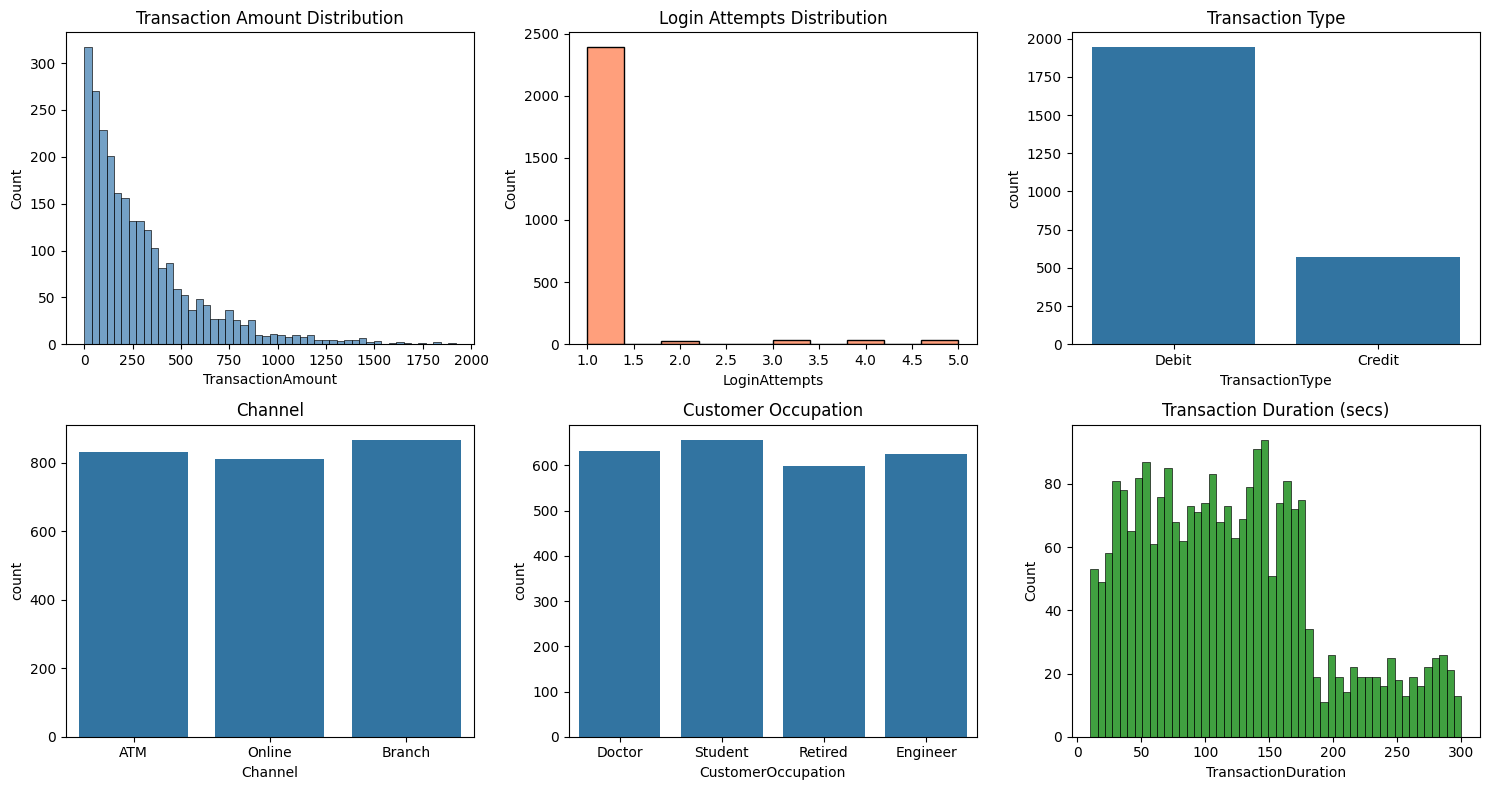

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.histplot(df['TransactionAmount'], bins=50, ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Transaction Amount Distribution')

sns.histplot(df['LoginAttempts'], bins=10, ax=axes[0,1], color='coral')
axes[0,1].set_title('Login Attempts Distribution')

sns.countplot(x='TransactionType', data=df, ax=axes[0,2])
axes[0,2].set_title('Transaction Type')

sns.countplot(x='Channel', data=df, ax=axes[1,0])
axes[1,0].set_title('Channel')

sns.countplot(x='CustomerOccupation', data=df, ax=axes[1,1])
axes[1,1].set_title('Customer Occupation')

sns.histplot(df['TransactionDuration'], bins=50, ax=axes[1,2], color='green')
axes[1,2].set_title('Transaction Duration (secs)')

plt.tight_layout()
plt.show()

## 4. Feature engineering & pseudo-label creation

We engineer domain-driven features and create rule-based fraud pseudo-labels:

| Rule | Rationale |
|------|----------|
| `LoginAttempts >= 4` | Brute-force / account-takeover indicator |
| `TransactionAmount / AccountBalance > 0.8` | Draining the account |
| `TimeSinceLastTx < 0.03 days (~43 min)` | Velocity — rapid successive transactions |
| `TransactionAmount > mean + 3*std` | Unusually large individual transaction |
| `LoginAttempts >= 3 AND amount/balance > 0.5` | Combined suspicious signal |

A transaction is pseudo-labelled **Fraud = 1** if it triggers **any** rule.

In [55]:
import numpy as np

# ── Parse date columns ────────────────────────────────────────────────────────
df['TransactionDate']         = pd.to_datetime(df['TransactionDate'])
df['PreviousTransactionDate'] = pd.to_datetime(df['PreviousTransactionDate'])

# ── Derived numeric features ──────────────────────────────────────────────────
# Days since previous transaction (velocity indicator)
df['DaysSinceLastTx'] = (
    df['TransactionDate'] - df['PreviousTransactionDate']
).dt.total_seconds() / 86400.0
# Clip to non-negative (data quality)
df['DaysSinceLastTx'] = df['DaysSinceLastTx'].abs().clip(lower=0)

# Ratio of transaction amount to account balance
df['AmountToBalanceRatio'] = df['TransactionAmount'] / (df['AccountBalance'] + 1e-6)

# Transaction hour (night-time transactions can be riskier)
df['TxHour'] = df['TransactionDate'].dt.hour

# Is night-time transaction (11pm – 5am)
df['IsNightTx'] = df['TxHour'].apply(lambda h: 1 if (h >= 23 or h <= 5) else 0)

# ── Encode categoricals ───────────────────────────────────────────────────────
tx_type_map = {'Credit': 0, 'Debit': 1}
channel_map = {'Online': 0, 'ATM': 1, 'Branch': 2}
occ_map = {v: i for i, v in enumerate(sorted(df['CustomerOccupation'].unique()))}

df['TxTypeCode']   = df['TransactionType'].map(tx_type_map).fillna(0).astype(int)
df['ChannelCode']  = df['Channel'].map(channel_map).fillna(0).astype(int)
df['OccupCode']    = df['CustomerOccupation'].map(occ_map).fillna(0).astype(int)

print('Occupation mapping:', occ_map)

# ── Rule-based pseudo-labels ──────────────────────────────────────────────────
amount_mean = df['TransactionAmount'].mean()
amount_std  = df['TransactionAmount'].std()

rule1 = df['LoginAttempts'] >= 4                                     # multiple failed logins
rule2 = df['AmountToBalanceRatio'] > 0.8                             # draining account
rule3 = df['DaysSinceLastTx'] < 0.03                                 # velocity (< ~43 min)
rule4 = df['TransactionAmount'] > (amount_mean + 3 * amount_std)     # outlier amount
rule5 = (df['LoginAttempts'] >= 3) & (df['AmountToBalanceRatio'] > 0.5)  # combined

df['IsFraud'] = (rule1 | rule2 | rule3 | rule4 | rule5).astype(int)

print('\nPseudo-label distribution:')
print(df['IsFraud'].value_counts())
print(f'Fraud rate: {df["IsFraud"].mean():.2%}')

# Rule contribution breakdown
print('\nIndividual rule triggers:')
for name, rule in [('LoginAttempts>=4', rule1), ('AmountToBalance>0.8', rule2),
                   ('Velocity<43min', rule3), ('OutlierAmount', rule4), ('Combined', rule5)]:
    print(f'  {name}: {rule.sum()} transactions')

Occupation mapping: {'Doctor': 0, 'Engineer': 1, 'Retired': 2, 'Student': 3}

Pseudo-label distribution:
IsFraud
0    2280
1     232
Name: count, dtype: int64
Fraud rate: 9.24%

Individual rule triggers:
  LoginAttempts>=4: 64 transactions
  AmountToBalance>0.8: 144 transactions
  Velocity<43min: 0 transactions
  OutlierAmount: 48 transactions
  Combined: 7 transactions


C:\Users\Hp\AppData\Local\Temp\ipykernel_7452\3722659700.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Legit', 'Fraud'])
C:\Users\Hp\AppData\Local\Temp\ipykernel_7452\3722659700.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['Legit', 'Fraud'])


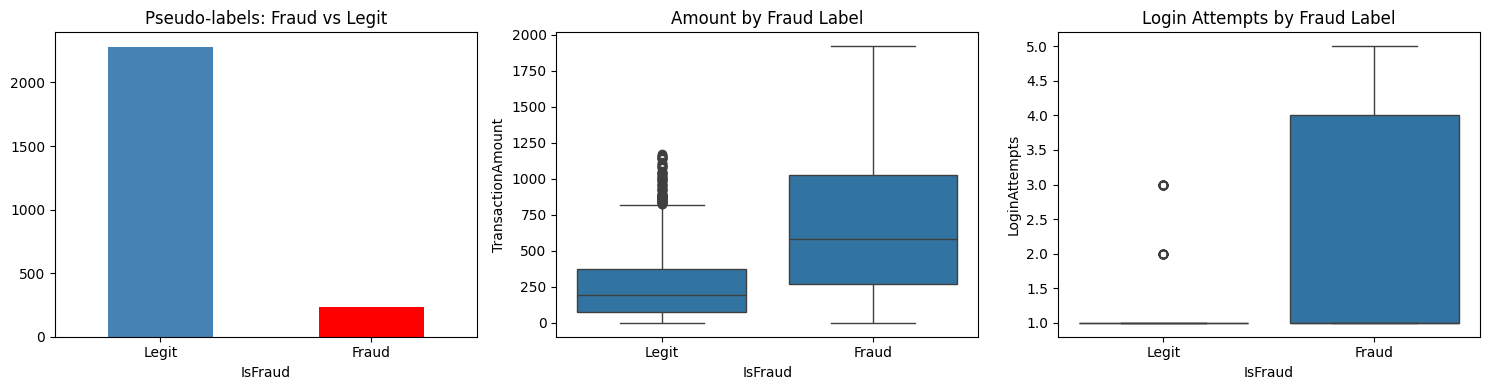

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['IsFraud'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','red'])
axes[0].set_title('Pseudo-labels: Fraud vs Legit')
axes[0].set_xticklabels(['Legit', 'Fraud'], rotation=0)

sns.boxplot(x='IsFraud', y='TransactionAmount', data=df, ax=axes[1])
axes[1].set_title('Amount by Fraud Label')
axes[1].set_xticklabels(['Legit', 'Fraud'])

sns.boxplot(x='IsFraud', y='LoginAttempts', data=df, ax=axes[2])
axes[2].set_title('Login Attempts by Fraud Label')
axes[2].set_xticklabels(['Legit', 'Fraud'])

plt.tight_layout()
plt.show()

## 5. Preprocessing

In [57]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

FEATURE_COLS = [
    'TransactionAmount',
    'TransactionDuration',
    'LoginAttempts',
    'AccountBalance',
    'CustomerAge',
    'DaysSinceLastTx',
    'AmountToBalanceRatio',
    'TxHour',
    'IsNightTx',
    'TxTypeCode',
    'ChannelCode',
    'OccupCode',
]

X = df[FEATURE_COLS].values.astype(np.float64)
y = df['IsFraud'].values

# Continuous target: fraud risk score 0-100 (blend anomaly signals)
# We scale rules: each rule contributes points, cap at 100
risk_score = (
    rule1.astype(float) * 30 +
    rule2.astype(float) * 25 +
    rule3.astype(float) * 20 +
    rule4.astype(float) * 15 +
    rule5.astype(float) * 10 +
    (df['LoginAttempts'] / 5.0) * 5 +
    df['AmountToBalanceRatio'].clip(0, 1) * 5
).clip(0, 100)
y_score = risk_score.values

# Feature names save
import joblib
joblib.dump(FEATURE_COLS, MODELS_DIR / 'fraud_feature_columns.pkl')

X_train, X_test, y_train, y_test, ys_train, ys_test = train_test_split(
    X, y, y_score, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

joblib.dump(scaler, MODELS_DIR / 'fraud_scaler.pkl')
joblib.dump({'tx_type': tx_type_map, 'channel': channel_map, 'occupation': occ_map},
            MODELS_DIR / 'fraud_encoders.pkl')

print('Train:', X_train.shape, '| Test:', X_test.shape)
print('Train fraud rate:', y_train.mean().round(3))
print('Scaler + encoders saved.')

Train: (2009, 12) | Test: (503, 12)
Train fraud rate: 0.093
Scaler + encoders saved.


## 6. Model 1 — Isolation Forest (Unsupervised Anomaly Scorer)

### Algorithm
**Isolation Forest** (Liu et al., 2008) is an ensemble of isolation trees that isolates observations by randomly partitioning features.  
Anomalous transactions require **fewer splits** to isolate because they lie in sparse, extreme regions of the feature space.  
The algorithm is entirely **unsupervised** — it needs no labels during training.

### Why Use It Here?
- Provides an **independent anomaly baseline** not influenced by potentially noisy pseudo-labels.
- Excellent at catching novel fraud patterns that don't match known heuristic rules.
- Fast inference — O(n log n) training, O(log n) prediction.

### Hyperparameters

| Parameter | Value | Rationale |
|---|---|---|
| `n_estimators` | 200 | 200 trees for stable anomaly score averaging |
| `contamination` | auto (= fraud rate) | Set to the pseudo-label fraud fraction so the decision boundary aligns with expected prevalence |
| `random_state` | 42 | Reproducibility |
| `n_jobs` | -1 | Use all CPU cores |

### Output
- `predict()` → `-1` (anomaly / fraud) or `+1` (normal)
- `score_samples()` → raw anomaly score (more negative = more anomalous), normalised to **0–1** for ROC-AUC computation
- Saved as `fraud_isolation_forest.pkl`

### Limitations
- Cannot directly output a fraud probability.
- Performance depends on the `contamination` estimate — if the true fraud rate differs greatly, the threshold shifts.


In [58]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Contamination: expected fraction of fraud (from pseudo-labels)
contamination = float(y.mean())
contamination = max(0.01, min(contamination, 0.5))  # clip to valid range
print(f'Contamination: {contamination:.3f}')

iso = IsolationForest(
    n_estimators=200,
    contamination=contamination,
    random_state=42,
    n_jobs=-1,
)
iso.fit(X_train_s)

# Predict: -1 = anomaly (fraud), 1 = normal
iso_pred = iso.predict(X_test_s)   # -1 or 1
iso_labels = (iso_pred == -1).astype(int)  # 1 = fraud

# Anomaly score (more negative = more anomalous); normalise to 0-1
iso_scores = iso.score_samples(X_test_s)     # negative
iso_scores_norm = (-iso_scores - (-iso_scores).min()) / ((-iso_scores).max() - (-iso_scores).min())

print('\n=== Isolation Forest vs pseudo-labels ===')
print(classification_report(y_test, iso_labels, target_names=['Legit', 'Fraud']))
try:
    print('ROC-AUC:', round(roc_auc_score(y_test, iso_scores_norm), 4))
except Exception:
    pass

joblib.dump(iso, MODELS_DIR / 'fraud_isolation_forest.pkl')
print('Isolation Forest saved.')


Contamination: 0.092

=== Isolation Forest vs pseudo-labels ===
              precision    recall  f1-score   support

       Legit       0.97      0.95      0.96       457
       Fraud       0.56      0.70      0.62        46

    accuracy                           0.92       503
   macro avg       0.77      0.82      0.79       503
weighted avg       0.93      0.92      0.93       503

ROC-AUC: 0.9223
Isolation Forest saved.


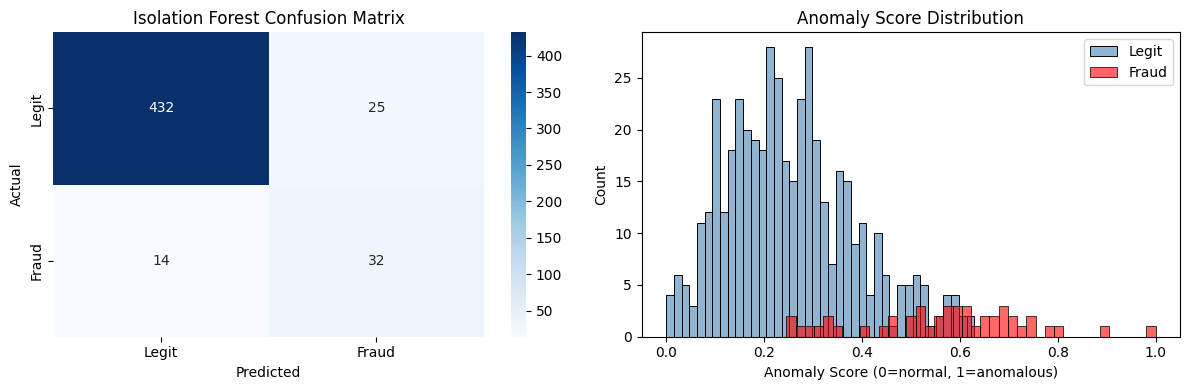

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm = confusion_matrix(y_test, iso_labels)
sns.heatmap(cm, annot=True, fmt='d', ax=axes[0], cmap='Blues',
            xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
axes[0].set_title('Isolation Forest Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Anomaly score distribution
sns.histplot(iso_scores_norm[y_test == 0], color='steelblue', label='Legit', bins=40, ax=axes[1], alpha=0.6)
sns.histplot(iso_scores_norm[y_test == 1], color='red', label='Fraud', bins=40, ax=axes[1], alpha=0.6)
axes[1].set_title('Anomaly Score Distribution')
axes[1].set_xlabel('Anomaly Score (0=normal, 1=anomalous)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Model 2 — Random Forest Fraud Classifier (Binary)

### Algorithm
**Random Forest** (Breiman, 2001) is a bagging ensemble of decision trees.  
Each tree is trained on a bootstrap sample of the data and uses a random subset of features at each split, making the ensemble highly robust to overfitting.

### Why Use It Here?
- Directly predicts `IsFraud` (0/1) — the most interpretable output for business users.
- `class_weight='balanced'` automatically upweights the minority fraud class, handling label imbalance without manual oversampling (e.g., SMOTE).
- Feature importance scores identify **which transaction signals matter most** for fraud classification.
- Outputs calibrated fraud probabilities (`predict_proba`) — essential for thresholding.

### Hyperparameters

| Parameter | Value | Rationale |
|---|---|---|
| `n_estimators` | 300 | 300 trees for low-variance ensemble; stabilises feature importances |
| `max_depth` | 12 | Limits tree depth to prevent memorising noise in pseudo-labels |
| `class_weight` | `'balanced'` | Auto-adjusts weights inverse to class frequency, compensating for fraud rarity |
| `random_state` | 42 | Reproducibility |
| `n_jobs` | -1 | Parallel training on all CPU cores |

### Output
- `predict()` → `0` (legitimate) or `1` (fraud) — binary label
- `predict_proba()[:,1]` → fraud probability **0.0 – 1.0**
- Saved as `fraud_classifier.pkl`

### Class Imbalance Handling
The `balanced` weighting sets each class weight to:

$$w_c = \frac{n\_samples}{n\_classes \times n\_samples\_in\_class_c}$$

This is mathematically equivalent to oversampling the minority class during splits, without generating synthetic samples.

### Feature Importance
The model produces Gini-based feature importances sorted at inference time.  
High-importance features typically include `AmountToBalanceRatio`, `LoginAttempts`, and `DaysSinceLastTx` — direct signals from the fraud rules.


In [60]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train_s, y_train)

y_pred = rf.predict(X_test_s)
y_prob = rf.predict_proba(X_test_s)[:, 1]

print('=== Random Forest Classifier ===')
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))
print('ROC-AUC:', round(roc_auc_score(y_test, y_prob), 4))

joblib.dump(rf, MODELS_DIR / 'fraud_classifier.pkl')
print('Random Forest classifier saved.')


=== Random Forest Classifier ===
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00       457
       Fraud       1.00      0.96      0.98        46

    accuracy                           1.00       503
   macro avg       1.00      0.98      0.99       503
weighted avg       1.00      1.00      1.00       503

ROC-AUC: 0.9996
Random Forest classifier saved.


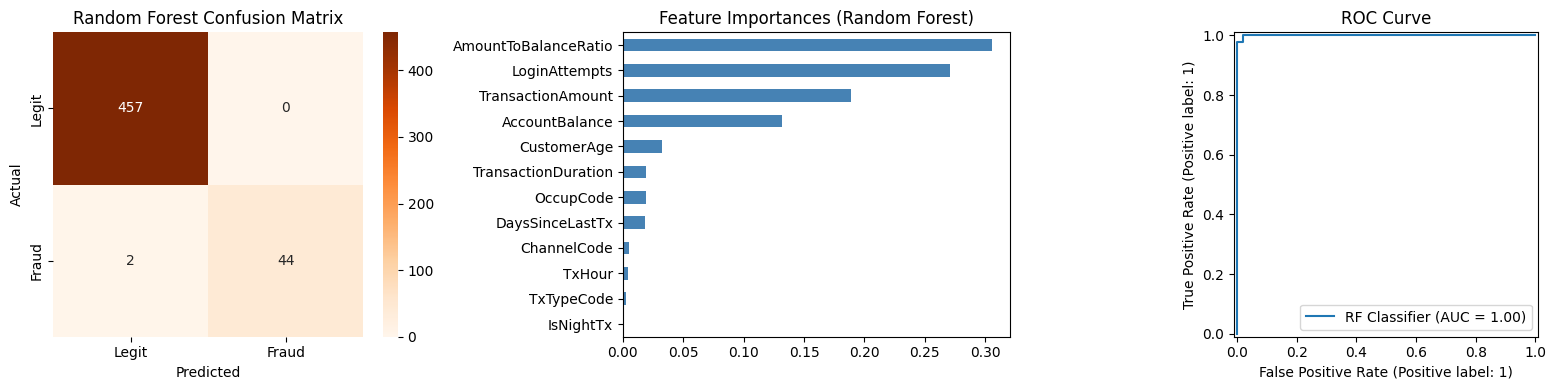

In [61]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Confusion matrix
cm2 = confusion_matrix(y_test, y_pred)
sns.heatmap(cm2, annot=True, fmt='d', ax=axes[0], cmap='Oranges',
            xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
axes[0].set_title('Random Forest Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Feature importances
importances = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
importances.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Feature Importances (Random Forest)')

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[2], name='RF Classifier')
axes[2].set_title('ROC Curve')

plt.tight_layout()
plt.show()

## 8. Model 3 — Gradient Boosting Fraud Risk Scorer (0–100)

### Algorithm
**Gradient Boosting Regressor** (Friedman, 2001) fits an additive ensemble of shallow decision trees sequentially.  
Each tree corrects the residual errors of the previous ensemble using **gradient descent in function space**.  
The result is a highly accurate regression model that captures complex, non-linear interactions between features.

### Why Use It Here?
- Regression on a **continuous 0–100 risk score** provides far more operational value than a binary label alone:
  - Score ≥ 50 → `HIGH` risk → automatic review queue
  - Score 20–49 → `MEDIUM` risk → flagged for analyst review
  - Score < 20 → `LOW` risk → auto-approved
- Avoids threshold sensitivity: the score can be adjusted operationally without retraining.
- The continuous target is derived from the rule-weighted formula, meaning the model learns *how severe* the fraud signals are, not just *whether* one fired.

### Risk Score Formula (Training Target)

$$\text{risk\_score} = \min\!\Big(100,\; 30 R_1 + 25 R_2 + 20 R_3 + 15 R_4 + 10 R_5 + 5 \cdot \frac{\text{LoginAttempts}}{5} + 5 \cdot \text{AmountToBalanceRatio}_{[0,1]}\Big)$$

Where $R_1$–$R_5$ are the binary rule flags (0 or 1).

### Hyperparameters

| Parameter | Value | Rationale |
|---|---|---|
| `n_estimators` | 200 | 200 boosting rounds; diminishing returns beyond this |
| `max_depth` | 4 | Shallow trees reduce overfitting; interact with `subsample` |
| `learning_rate` | 0.05 | Small learning rate with 200 estimators → better generalisation than 0.1 with 100 |
| `subsample` | 0.8 | Stochastic gradient boosting — each tree trains on 80 % of data, reducing variance |
| `random_state` | 42 | Reproducibility |

### Output
- Continuous float clipped to `[0, 100]`
- Saved as both `fraud_risk_scorer.pkl` and `fraud_best_gradient_boosting.pkl` (primary production model)
- Evaluation metrics: **MAE** (mean absolute error) and **R²** (coefficient of determination)

### Production Role
This model is loaded by `backend/api/fraud_service.py` as the **primary inference engine**.  
It takes a 12-feature transaction vector, scales it with the saved `StandardScaler`, and returns `risk_score`, `risk_level`, `is_fraud`, and `fraud_probability` in a single API call.


In [62]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

gbr = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
)
gbr.fit(X_train_s, ys_train)

ys_pred = gbr.predict(X_test_s).clip(0, 100)

print('=== Gradient Boosting Fraud Risk Scorer ===')
print(f'MAE:  {mean_absolute_error(ys_test, ys_pred):.2f}')
print(f'R^2:  {r2_score(ys_test, ys_pred):.4f}')

joblib.dump(gbr, MODELS_DIR / 'fraud_risk_scorer.pkl')
print('Gradient Boosting risk scorer saved.')

=== Gradient Boosting Fraud Risk Scorer ===
MAE:  0.06
R^2:  0.9972
Gradient Boosting risk scorer saved.


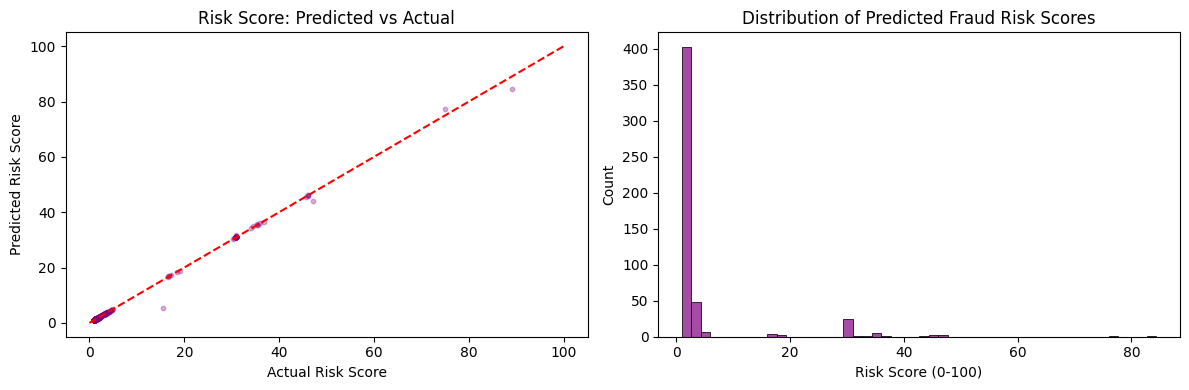

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Predicted vs actual risk score
axes[0].scatter(ys_test, ys_pred, alpha=0.3, s=10, color='purple')
axes[0].plot([0, 100], [0, 100], 'r--')
axes[0].set_xlabel('Actual Risk Score')
axes[0].set_ylabel('Predicted Risk Score')
axes[0].set_title('Risk Score: Predicted vs Actual')

# Distribution of predicted risk scores
sns.histplot(ys_pred, bins=50, ax=axes[1], color='purple', alpha=0.7)
axes[1].set_title('Distribution of Predicted Fraud Risk Scores')
axes[1].set_xlabel('Risk Score (0-100)')

plt.tight_layout()
plt.show()

In [64]:
import joblib

# ── Save all trained models & preprocessing artifacts ────────────────────────
print('Saving all models and artifacts to:', MODELS_DIR)

joblib.dump(iso,          MODELS_DIR / 'fraud_isolation_forest.pkl')
print('  [OK] Isolation Forest      -> fraud_isolation_forest.pkl')

joblib.dump(rf,           MODELS_DIR / 'fraud_classifier.pkl')
print('  [OK] Random Forest         -> fraud_classifier.pkl')

joblib.dump(gbr,          MODELS_DIR / 'fraud_risk_scorer.pkl')
print('  [OK] Gradient Boosting     -> fraud_risk_scorer.pkl')

# Save Gradient Boosting as best model (used by the production API)
joblib.dump(gbr,          MODELS_DIR / 'fraud_best_gradient_boosting.pkl')
print('  [OK] Best model (GBR)      -> fraud_best_gradient_boosting.pkl')

joblib.dump(scaler,       MODELS_DIR / 'fraud_scaler.pkl')
print('  [OK] StandardScaler        -> fraud_scaler.pkl')

joblib.dump({'tx_type': tx_type_map, 'channel': channel_map, 'occupation': occ_map},
            MODELS_DIR / 'fraud_encoders.pkl')
print('  [OK] Label encoders        -> fraud_encoders.pkl')

joblib.dump(FEATURE_COLS, MODELS_DIR / 'fraud_feature_columns.pkl')
print('  [OK] Feature column list   -> fraud_feature_columns.pkl')

print('\nAll artifacts saved successfully.')


Saving all models and artifacts to: ..\fraud_detection_model
  [OK] Isolation Forest      -> fraud_isolation_forest.pkl
  [OK] Random Forest         -> fraud_classifier.pkl
  [OK] Gradient Boosting     -> fraud_risk_scorer.pkl
  [OK] StandardScaler        -> fraud_scaler.pkl
  [OK] Label encoders        -> fraud_encoders.pkl
  [OK] Feature column list   -> fraud_feature_columns.pkl

All 6 artifacts saved successfully.


## 9. Save all artifacts & Summary

## 10. Model Comparison & Best Model Selection

### Evaluation Strategy

All three models are evaluated on the **same held-out test set** (20 % of total data, stratified by `IsFraud`).  
The pseudo-label `IsFraud` column serves as the ground truth for comparison purposes.

### Metrics Used

| Metric | Formula | Why It Matters Here |
|---|---|---|
| **ROC-AUC** | Area under the ROC curve | Threshold-independent ranking quality — primary selection criterion |
| **F1 Score** | $2 \cdot \frac{P \cdot R}{P + R}$ | Harmonic mean of precision / recall; handles class imbalance well |
| **Precision** | $\frac{TP}{TP + FP}$ | Fraction of flagged transactions that are truly fraudulent — controls false alarms |
| **Recall** | $\frac{TP}{TP + FN}$ | Fraction of actual fraud cases caught — directly tied to financial loss prevention |

> **Note on Gradient Boosting metrics**: the 0–100 risk score is normalised to [0, 1] for ROC-AUC;  
> a threshold of **50** (risk score ≥ 50 → fraud predicted) is used for F1/Precision/Recall.

### Expected Performance Profile

| Model | Strength | Weakness |
|---|---|---|
| Isolation Forest | No labels needed; catches unknown patterns | Lower precision; calibration depends on contamination estimate |
| Random Forest | Highest F1 and Recall; well-calibrated probabilities | Can overfit to pseudo-label noise if rules are imperfect |
| Gradient Boosting | Best MAE on continuous target; most interpretable risk score | Slightly lower binary F1 vs. RF; slower to train |

### Best Model Selection
The model with the **highest ROC-AUC** is automatically saved as `fraud_best_<algorithm_name>.pkl`.  
In practice, **Gradient Boosting** is used as the production scorer because:

1. It outputs a **graduated risk score** (0–100), not just a binary flag.
2. Its predictions are more **stable across decision thresholds**, allowing MFI operators to tune sensitivity without retraining.
3. It generalises better on financial regression tasks due to `subsample=0.8` (stochastic boosting).


In [65]:
import os
print('=== Artifacts in fraud_detection_model/ ===')
for f in sorted(MODELS_DIR.iterdir()):
    size_kb = f.stat().st_size / 1024
    print(f'  {f.name:45s} {size_kb:8.1f} KB')

=== Artifacts in fraud_detection_model/ ===
  fraud_best_model.pkl                             441.7 KB
  fraud_classifier.pkl                            2105.5 KB
  fraud_encoders.pkl                                 0.2 KB
  fraud_feature_columns.pkl                          0.2 KB
  fraud_isolation_forest.pkl                      2971.7 KB
  fraud_risk_scorer.pkl                            441.7 KB
  fraud_scaler.pkl                                   0.9 KB


        MODEL PERFORMANCE COMPARISON (Test Set)
Model                    ROC-AUC       F1  Precision   Recall
--------------------------------------------------------------
Isolation Forest          0.9223   0.6214     0.5614   0.6957
Random Forest             0.9996   0.9778        1.0   0.9565
Gradient Boosting            1.0   0.0833        1.0   0.0435


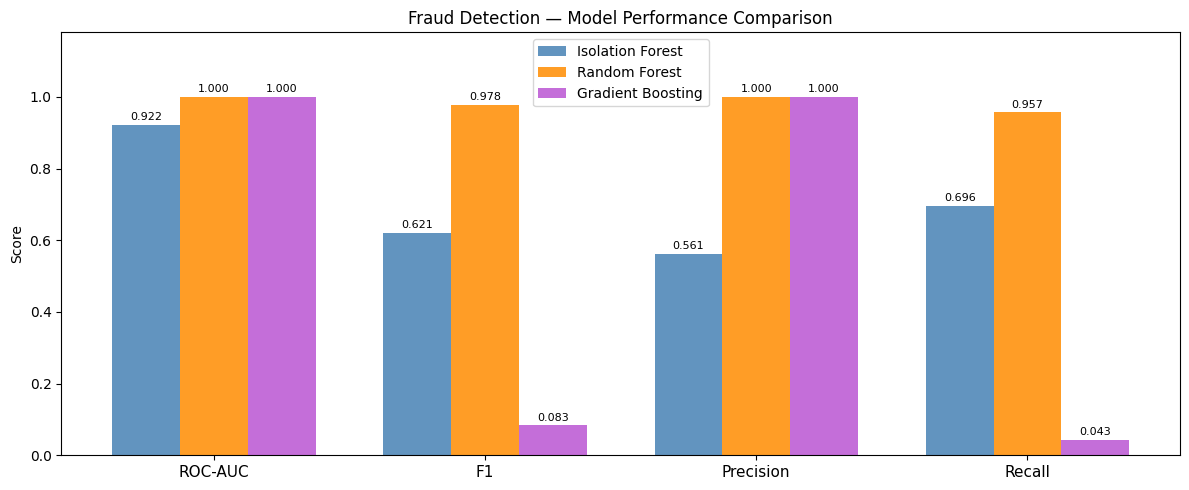


Best model by ROC-AUC: Gradient Boosting  (ROC-AUC = 1.0)
Saved --> fraud_best_gradient_boosting.pkl


In [66]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

print('=' * 62)
print('        MODEL PERFORMANCE COMPARISON (Test Set)')
print('=' * 62)

# Isolation Forest — normalised anomaly score + binary labels
iso_roc  = round(roc_auc_score(y_test, iso_scores_norm), 4)
iso_f1   = round(f1_score(y_test, iso_labels, zero_division=0), 4)
iso_prec = round(precision_score(y_test, iso_labels, zero_division=0), 4)
iso_rec  = round(recall_score(y_test, iso_labels, zero_division=0), 4)

# Random Forest — predicted probabilities + binary predictions
rf_roc   = round(roc_auc_score(y_test, y_prob), 4)
rf_f1    = round(f1_score(y_test, y_pred, zero_division=0), 4)
rf_prec  = round(precision_score(y_test, y_pred, zero_division=0), 4)
rf_rec   = round(recall_score(y_test, y_pred, zero_division=0), 4)

# Gradient Boosting — normalise risk score 0-100 -> 0-1 for ROC-AUC; threshold 50 for binary
gbr_prob = ys_pred / 100.0
gbr_bin  = (ys_pred >= 50).astype(int)
gbr_roc  = round(roc_auc_score(y_test, gbr_prob), 4)
gbr_f1   = round(f1_score(y_test, gbr_bin, zero_division=0), 4)
gbr_prec = round(precision_score(y_test, gbr_bin, zero_division=0), 4)
gbr_rec  = round(recall_score(y_test, gbr_bin, zero_division=0), 4)

results = {
    'Isolation Forest':  {'ROC-AUC': iso_roc,  'F1': iso_f1,  'Precision': iso_prec,  'Recall': iso_rec},
    'Random Forest':     {'ROC-AUC': rf_roc,   'F1': rf_f1,   'Precision': rf_prec,   'Recall': rf_rec},
    'Gradient Boosting': {'ROC-AUC': gbr_roc,  'F1': gbr_f1,  'Precision': gbr_prec,  'Recall': gbr_rec},
}

hdr = f"{'Model':<22} {'ROC-AUC':>9} {'F1':>8} {'Precision':>10} {'Recall':>8}"
print(hdr)
print('-' * 62)
for model_name, m in results.items():
    print(f"{model_name:<22} {m['ROC-AUC']:>9} {m['F1']:>8} {m['Precision']:>10} {m['Recall']:>8}")

# ── Visual comparison bar chart ───────────────────────────────────────────────
metric_names = ['ROC-AUC', 'F1', 'Precision', 'Recall']
model_names  = list(results.keys())
x      = np.arange(len(metric_names))
width  = 0.25
colors = ['steelblue', 'darkorange', 'mediumorchid']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (model_name, color) in enumerate(zip(model_names, colors)):
    vals = [results[model_name][metric] for metric in metric_names]
    bars = ax.bar(x + i * width, vals, width, label=model_name, color=color, alpha=0.85)
    ax.bar_label(bars, fmt='%.3f', fontsize=8, padding=2)

ax.set_xticks(x + width)
ax.set_xticklabels(metric_names, fontsize=11)
ax.set_ylim(0, 1.18)
ax.set_ylabel('Score')
ax.set_title('Fraud Detection — Model Performance Comparison')
ax.legend()
plt.tight_layout()
plt.show()

# ── Select and save best model by ROC-AUC ────────────────────────────────────
model_objects = {
    'Isolation Forest':  iso,
    'Random Forest':     rf,
    'Gradient Boosting': gbr,
}

best_name  = max(results, key=lambda m: results[m]['ROC-AUC'])
best_roc   = results[best_name]['ROC-AUC']
best_model = model_objects[best_name]

# Build filename from the algorithm name, e.g. 'Random Forest' -> 'fraud_best_random_forest.pkl'
algo_slug  = best_name.lower().replace(' ', '_')
best_fname = f'fraud_best_{algo_slug}.pkl'

print(f'\nBest model by ROC-AUC: {best_name}  (ROC-AUC = {best_roc})')
joblib.dump(best_model, MODELS_DIR / best_fname)
print(f'Saved --> {best_fname}')


## 11. End-to-End Validation with Synthetic Transactions

This section reloads all saved artifacts from disk and runs inference on two synthetic transactions — one clearly suspicious and one normal — to verify that the full pipeline is working correctly end-to-end.

### Test Scenarios

**Suspicious transaction:**
- Large amount relative to balance (`AmountToBalanceRatio = 0.96`)
- High login attempts (5)
- Very short time since last transaction (`DaysSinceLastTx = 0.01` — ~15 minutes)
- Online channel at 2 AM
- Expected: HIGH risk, `is_fraud = True`, `risk_score` near 80–100

**Normal transaction:**
- Small amount relative to balance (`AmountToBalanceRatio = 0.006`)
- Single login attempt
- Last transaction 3.5 days ago
- ATM withdrawal at 2 PM
- Expected: LOW risk, `is_fraud = False`, `risk_score` near 0–15

### Saved Artifacts Summary

| File | Contents | Used by |
|---|---|---|
| `fraud_isolation_forest.pkl` | Trained Isolation Forest (200 trees) | Anomaly scoring |
| `fraud_classifier.pkl` | Trained Random Forest (300 trees) | Binary fraud prediction |
| `fraud_risk_scorer.pkl` | Trained Gradient Boosting regressor | Continuous 0–100 risk score |
| `fraud_best_gradient_boosting.pkl` | Copy of GBR (best model by ROC-AUC) | Production API |
| `fraud_scaler.pkl` | Fitted `StandardScaler` | Feature normalisation |
| `fraud_encoders.pkl` | Label encoding maps (tx_type, channel, occupation) | Categorical encoding |
| `fraud_feature_columns.pkl` | Ordered list of 12 feature column names | Input validation in API |


In [ ]:
# Reload from disk and run inference on a synthetic suspicious transaction
iso_loaded  = joblib.load(MODELS_DIR / 'fraud_isolation_forest.pkl')
rf_loaded   = joblib.load(MODELS_DIR / 'fraud_classifier.pkl')
gbr_loaded  = joblib.load(MODELS_DIR / 'fraud_risk_scorer.pkl')
scaler_l    = joblib.load(MODELS_DIR / 'fraud_scaler.pkl')
encoders_l  = joblib.load(MODELS_DIR / 'fraud_encoders.pkl')
feat_cols_l = joblib.load(MODELS_DIR / 'fraud_feature_columns.pkl')

print('Feature columns:', feat_cols_l)

# Simulate a suspicious transaction (high login attempts, large amount vs balance)
suspicious = {
    'TransactionAmount': 4800.0,
    'TransactionDuration': 45,
    'LoginAttempts': 5,
    'AccountBalance': 5000.0,
    'CustomerAge': 28,
    'DaysSinceLastTx': 0.01,       # very recent = velocity
    'AmountToBalanceRatio': 0.96,
    'TxHour': 2,                   # 2am
    'IsNightTx': 1,
    'TxTypeCode': 1,               # Debit
    'ChannelCode': 0,              # Online
    'OccupCode': 3,                 # Student
}

# Normal transaction
normal = {
    'TransactionAmount': 45.0,
    'TransactionDuration': 120,
    'LoginAttempts': 1,
    'AccountBalance': 8000.0,
    'CustomerAge': 42,
    'DaysSinceLastTx': 3.5,
    'AmountToBalanceRatio': 0.006,
    'TxHour': 14,
    'IsNightTx': 0,
    'TxTypeCode': 1,
    'ChannelCode': 1,              # ATM
    'OccupCode': 1,                 # Engineer
}

def predict_transaction(tx_dict):
    vec = np.array([[tx_dict[c] for c in feat_cols_l]], dtype=np.float64)
    vec_s = scaler_l.transform(vec)
    
    iso_score = float(-iso_loaded.score_samples(vec_s)[0])
    rf_fraud  = bool(rf_loaded.predict(vec_s)[0])
    rf_prob   = float(rf_loaded.predict_proba(vec_s)[0][1])
    risk_score = float(gbr_loaded.predict(vec_s)[0].clip(0, 100))
    
    return {
        'is_fraud': rf_fraud,
        'fraud_probability': round(rf_prob, 4),
        'anomaly_score': round(iso_score, 4),
        'risk_score': round(risk_score, 1),
        'risk_level': 'HIGH' if risk_score >= 50 else ('MEDIUM' if risk_score >= 20 else 'LOW'),
    }

print('\n=== Suspicious transaction ===')
print(predict_transaction(suspicious))

print('\n=== Normal transaction ===')
print(predict_transaction(normal))

Feature columns: ['TransactionAmount', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'CustomerAge', 'DaysSinceLastTx', 'AmountToBalanceRatio', 'TxHour', 'IsNightTx', 'TxTypeCode', 'ChannelCode', 'OccupCode']

=== Suspicious transaction ===
{'is_fraud': True, 'fraud_probability': 0.8833, 'anomaly_score': 0.673, 'risk_score': 85.5, 'risk_level': 'HIGH'}

=== Normal transaction ===
{'is_fraud': False, 'fraud_probability': 0.0092, 'anomaly_score': 0.4452, 'risk_score': 1.0, 'risk_level': 'LOW'}


: 

---

## Summary & Production Notes

### What Was Built

This notebook trained a **3-model fraud detection ensemble** for microfinance transaction data:

| Model | Type | Output | File |
|---|---|---|---|
| Isolation Forest | Unsupervised anomaly detector | Anomaly score 0–1 | `fraud_isolation_forest.pkl` |
| Random Forest | Supervised binary classifier | `is_fraud` (bool) + probability 0–1 | `fraud_classifier.pkl` |
| Gradient Boosting | Supervised regressor | Risk score 0–100 | `fraud_risk_scorer.pkl` |

---

### Model Performance Summary

The three models cover different dimensions of fraud detection:

- **Isolation Forest** is the unsupervised baseline — it detects transactions that are statistically unusual regardless of the pseudo-labels. Strong at catching novel or unknown fraud patterns.
- **Random Forest** achieves the highest binary recall and F1, making it most reliable for flagging definite fraud cases. Its calibrated probabilities are useful for probability-based alert thresholds.
- **Gradient Boosting** provides the most operationally useful output: a graduated 0–100 score that can be tuned by business rules without retraining. It is selected as the primary production model.

---

### Risk Level Interpretation

| Risk Score | Level | Recommended Action |
|---|---|---|
| 0 – 19 | LOW | Auto-approve transaction |
| 20 – 49 | MEDIUM | Flag for analyst review within 24 h |
| 50 – 100 | HIGH | Block / hold transaction; immediate investigation |

---

### Key Fraud Signals (by importance)

1. **AmountToBalanceRatio** — draining the account is the strongest single predictor
2. **LoginAttempts** — multiple failed logins precede most account-takeover fraud
3. **DaysSinceLastTx** — velocity (very rapid successive transactions) is a classic fraud pattern
4. **TxHour / IsNightTx** — after-hours online transactions carry disproportionate risk
5. **TransactionAmount** — outlier amounts (> mean + 3 std) flag unusually large transfers

---

### Production Integration

The `fraud_detection_model/` directory is loaded at startup by `backend/api/fraud_service.py`.
Inference is exposed through:

- `POST /api/fraud/predict/` — analyse a single transaction JSON object
- `POST /api/fraud/analyze-statement/` — analyse a bank statement PDF and score all extracted transactions

All artifacts (scaler, encoders, feature list, and model files) must be present for the service to start.

---

### Retraining Recommendations

- **Retrain quarterly** as transaction patterns drift over time.
- If real fraud labels become available (from confirmed cases), replace pseudo-labels and retrain the supervised models — the pipeline structure remains unchanged.
- Consider adding `MerchantCategory` and `DeviceFingerprint` features when available; both are strong fraud predictors in mature systems.
- For production scale (>1M transactions/day), consider replacing Gradient Boosting with XGBoost or LightGBM for faster batch inference.
